# Logistic Regression Implementation from Scratch

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('framingham.csv')
df.head()



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)  #(df - df.min()) / (df.max() - df.min())

In [4]:
# Check for missing values
print(df.isnull().sum())

# Replace missing values with a specific value
df = df.fillna(0)


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


In [5]:
#drop the education column
df = df.drop(df.columns[2], axis=1)



## Train/Validation/Test data
While training the model it is important to split the dataset which we are using. In practise, we split our dataset into three parts train dataset, val dataset and test dataset.
*   Train dataset is used train the model. You know the ground truth and using the ground truths values you can train it.
*   Validation dataset is not used to train the model rather it is used to test the model. The model trains on train dataset and makes predictions on validation dataset.
*   Test dataset is the final dataset on which we expect our model to make predictions.

The difference between validation and test dataset is in validation dataset we are aware of the ground truth values.


In [6]:
# Extracting features (X) and target variable (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

X_train = X_train.T
Y_train = y_train.reshape(1, X_train.shape[1])

X_test = X_test.T
Y_test = y_test.reshape(1, X_test.shape[1])



print("Shape of X_train : ", X_train.shape)
print("Shape of Y_train : ", Y_train.shape)
print("Shape of X_test : ", X_test.shape)
print("Shape of Y_test : ", Y_test.shape)

Shape of X_train :  (14, 3816)
Shape of Y_train :  (1, 3816)
Shape of X_test :  (14, 424)
Shape of Y_test :  (1, 424)


In [7]:
print(df.head())

   male       age  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0   1.0  0.184211            0.0    0.000000     0.0              0.0   
1   0.0  0.368421            0.0    0.000000     0.0              0.0   
2   1.0  0.421053            1.0    0.285714     0.0              0.0   
3   0.0  0.763158            1.0    0.428571     0.0              0.0   
4   0.0  0.368421            1.0    0.328571     0.0              0.0   

   prevalentHyp  diabetes   totChol     sysBP     diaBP       BMI  heartRate  \
0           0.0       0.0  0.149406  0.106383  0.232804  0.277024   0.363636   
1           0.0       0.0  0.242784  0.177305  0.349206  0.319680   0.515152   
2           0.0       0.0  0.234295  0.208038  0.338624  0.237518   0.313131   
3           1.0       0.0  0.200340  0.314421  0.497354  0.316045   0.212121   
4           0.0       0.0  0.302207  0.219858  0.380952  0.183228   0.414141   

    glucose  TenYearCHD  
0  0.104520         0.0  
1  0.101695         0.0  
2 

In [8]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))
def model(X, Y, learning_rate, iterations):
    m = X_train.shape[1]
    n = X_train.shape[0]

    W = np.random.randn(n, 1)
    B = 0

    cost_list = []

    for i in range(iterations):
        Z = np.dot(W.T, X) + B
        A = sigmoid(Z)

        cost = -(1/m) * np.sum(Y*np.log(A) + (1-Y)*np.log(1-A))

        # Gradient Descent
        dW = (1/m) * np.dot(A-Y, X.T)
        dB = (1/m) * np.sum(A - Y)

        W = W - learning_rate * dW.T
        B = B - learning_rate * dB

        # Keeping track of our cost function value
        cost_list.append(cost)

        if i % (iterations/10) == 0:
            print("cost after", i, "iteration is:", cost)

    return W, B, cost_list

def accuracy(X, Y, W, B):

    Z = np.dot(W.T, X) + B
    A = sigmoid(Z)

    A = A > 0.5

    A = np.array(A, dtype = 'int64')

    acc = (1 - np.sum(np.absolute(A - Y))/Y.shape[1])*100

    print("Accuracy of the model is : ", round(acc, 2), "%")

In [9]:
iterations = 120000
learning_rate = 0.0001
W, B, cost_list = model(X_train, Y_train, learning_rate = learning_rate, iterations = iterations)

cost after 0 iteration is: 1.73487195554226
cost after 12000 iteration is: 1.0583315138672351
cost after 24000 iteration is: 0.7663935828587819
cost after 36000 iteration is: 0.6460704268056079
cost after 48000 iteration is: 0.5932489707482159
cost after 60000 iteration is: 0.5669869225652424
cost after 72000 iteration is: 0.5517074265489149
cost after 84000 iteration is: 0.5412742915772911
cost after 96000 iteration is: 0.533132629325914
cost after 108000 iteration is: 0.5261622439980539


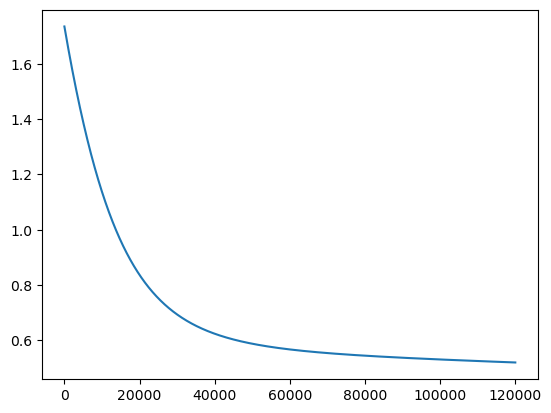

In [10]:
plt.plot(np.arange(iterations), cost_list)
plt.show()

In [11]:
accuracy(X_test, Y_test, W, B)

Accuracy of the model is :  86.08 %


In [12]:
df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1.0,0.184211,0.0,0.000000,0.0,0.0,0.0,0.0,0.149406,0.106383,0.232804,0.277024,0.363636,0.104520,0.0
1,0.0,0.368421,0.0,0.000000,0.0,0.0,0.0,0.0,0.242784,0.177305,0.349206,0.319680,0.515152,0.101695,0.0
2,1.0,0.421053,1.0,0.285714,0.0,0.0,0.0,0.0,0.234295,0.208038,0.338624,0.237518,0.313131,0.084746,0.0
3,0.0,0.763158,1.0,0.428571,0.0,0.0,1.0,0.0,0.200340,0.314421,0.497354,0.316045,0.212121,0.177966,1.0
4,0.0,0.368421,1.0,0.328571,0.0,0.0,0.0,0.0,0.302207,0.219858,0.380952,0.183228,0.414141,0.127119,0.0


# Logistic Regression Implementation using scikit-learn

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Create an instance of the logistic regression model
logreg = LogisticRegression()

# Fit the model on the training data
logreg.fit(X_train, y_train)

# Predict the target variable for the test data
y_pred = logreg.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred) #
print("Accuracy of the model is:", round(accuracy * 100, 2), "%")




Accuracy of the model is: 87.03 %
